# Linear Regression in Python

---

## 1. Introduction

This notebook demonstrates how to fit linear regression models in a Jupyter notebook using standard Python libraries and data from **NHANES**. NHANES is a complex, weighted survey (with strata and clusters) that ordinarily requires survey‑aware methods; in this notebook we ignore the survey design in order to illustrate regression techniques for independent or convenience samples.

We focus on models where **systolic blood pressure (SBP)** is the outcome (dependent) variable — that is, we  predict an individual’s SBP from other subject‑level variables. A domain expert has suggested several plausible predictors: age, body‑mass index (BMI), sex (or gender), and race/ethnicity, since SBP tends to increase with age, is higher among people with greater BMI, and varies across demographic groups.

Linear regression is a natural, easy‑to‑interpret starting point for modeling a quantitative outcome such as SBP. Note that the standard ordinary least squares (OLS) inference — which we use in this notebook — relies on assumptions such as linearity, independence, homoscedasticity, and, for some tests, approximately normal errors.

More complex approaches (e.g., multilevel/mixed‑effects models and marginal/GEE models) will be taught in Week 3; we start with OLS so you have a clear foundation in estimation, interpretation, and diagnostic checks that these later methods build on.

---

## 2. Import Libraries, Load and Prepare the Data
First, we import the standard libraries for data manipulation, visualization, and statistical modeling (e.g., pandas, numpy, matplotlib/seaborn, and statsmodels). 

Then we load the NHANES 2015–2016 data. NHANES includes multiple waves; this notebook uses only the 2015–2016 wave.

As with most datasets, NHANES contains missing values. For simplicity we perform a **complete‑case analysis**: we  drop observations with missing values in any of the key variables used in this notebook. 

> **Note:** Complete‑case analysis reduces the effective sample size and can bias estimates and standard errors unless the missingness mechanism is missing completely at random (MCAR). In practice you should consider alternatives such as single or multiple imputation, or other methods that explicitly model missingness.

After loading and cleaning, we rename columns to make variable names easier to work with (for readability and convenience).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Read the 2015-2016 wave of NHANES data
nhanes_df = pd.read_csv("./data/nhanes_2015_2016.csv")

# Select columns of interest and drop observations with missing values
cols = ["BPXSY1", "RIDAGEYR", "RIAGENDR", "BMXBMI"]
nhanes_df = nhanes_df[cols].dropna().reset_index(drop=True)

# Rename columns
nhanes_df = nhanes_df.rename(columns={"BPXSY1": "sbp", "RIDAGEYR" : "age", "RIAGENDR": "gender", "BMXBMI": "bmi"})

# Print the first 5 rows
nhanes_df.head()

,sbp,age,gender,bmi
0,128.0,62,1,27.8
1,146.0,53,1,30.8
2,138.0,78,1,28.8
3,132.0,56,2,42.4
4,100.0,42,2,20.3



---

## 3. Fitting a Simple Linear Regression Model
We start with a simple linear regression model that uses a single covariate, age, to predict systolic blood pressure (SBP).

In our dataframe, the variable `sbp` contains the first recorded SBP measurement for each subject and `age` is the subject's age in years. The formula `sbp ~ age` indicates that `sbp` is the response variable and `age` is the single predictor.

In [2]:
model = sm.OLS.from_formula("sbp ~ age", data=nhanes_df)
result = model.fit()
print(result.summary())
print("="*78)

                            OLS Regression Results                            
Dep. Variable:                    sbp   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     1522.
Date:                Thu, 23 Oct 2025   Prob (F-statistic):          3.09e-293
Time:                        10:30:18   Log-Likelihood:                -22487.
No. Observations:                5347   AIC:                         4.498e+04
Df Residuals:                    5345   BIC:                         4.499e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    102.4739      0.619    165.512      0.0

### Interpreting Regression Parameters

Let's focus on the center section of the OLS output where the header row begins with **coef**. That section shows the estimated regression parameters (the coefficients), their standard errors, t‑statistics, p‑values, and related quantities used to quantify uncertainty. Regression parameters are often called *slopes* or *effects*.

This fitted model implies that:
* When comparing two people whose ages differ by one year, the older person will on average have 0.47 units higher SPB than the younger person.
* This difference is statistically significant, based on the p-value of 0.000. In other words, there is a strong evidence that there is a real **association** between SBP and age in this population.

In order to better understand the meaning of the estimated regression parameter 0.47, we can look at the standard deviation of SBP:

In [3]:
print(nhanes_df["sbp"].std())

18.39333916033233


The standard deviation of SBP (18.4 units) is much greater than the yearly increase predicted by the regression slope (0.47 units per year). Even over a 20-year span, the average increase ($20 \cdot 0.47 = 9.4$ units) is only about half a standard deviation. This means that individual variation is large compared to the effect of age, so it is common for a younger person to have a higher SBP than an older person.

### R-squared vs. Correlation in Simple Linear Regression
In the case of regression with a single independent variable, as we have here, there is a very close correspondence between the regression analysis and a Pearson correlation analysis.

The primary summary statistic for assessing the strength of a predictive relationship in a linear regression model is the **R-squared**, which is shown to be 0.222 in the output above. This means that 22.2% of the variation in SBP is explained by age. Note that this value is exactly the same as the squared Pearson correlation coefficient between SBP and age, as shown below.

In [4]:
cc = nhanes_df[["sbp", "age"]].corr()
print(cc.sbp.age**2)

0.22167677636502015


The second way to interpret the R-squared makes use of the **fitted values** of the regression. The fitted values are predictions of the blood pressure for each person in the dataset, based on their covariate values.

If we calculate the Pearson correlation coefficient between the fitted values from the regression, and the actual SBP values, and then square this correlation coefficient, we see that we also get the R-squared from the regression:

In [5]:
cc = np.corrcoef(nhanes_df["sbp"], result.fittedvalues)
print(cc[0, 1]**2)

0.22167677636502134


Thus, we see that in a simple linear regression model, the regression R-squared is equal to the squared Pearson
correlation between the covariate and the outcome, and is also equal to the squared Pearson correlation between the fitted values and the outcome.

> **Note:** When we use a multiple linear regression model, we'll discover that only the second part of the statement above is true. 

---

## 4. Fitting a Multiple Linear Regression Model
The real power of regression analysis arises when we have more than one covariate predicting an outcome. Let's add `gender` to the model.

In [6]:
# Create a labeled version of the gender variable
nhanes_df["gender_labeled"] = nhanes_df["gender"].replace({1: "Male", 2:"Female"})

# Fit the multiple linear regression model
model = sm.OLS.from_formula("sbp ~ age + gender_labeled", data=nhanes_df)
result = model.fit()
print(result.summary())
print("="*78)

                            OLS Regression Results                            
Dep. Variable:                    sbp   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     799.8
Date:                Thu, 23 Oct 2025   Prob (F-statistic):          1.42e-304
Time:                        10:30:18   Log-Likelihood:                -22457.
No. Observations:                5347   AIC:                         4.492e+04
Df Residuals:                    5344   BIC:                         4.494e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                100

### Interpreting Regression Parameters
The model that was fit above uses both age and gender to explain the variation in SBP.  It finds that:

* Two people with the same gender whose ages differ by one year tend to have blood pressure values differing by 0.47 units.
* This model also shows us that comparing a male and a female person of the same age, the male will on average have 3.43 units greater SBP than the female.

When interpreting the parameters of this multiple regression model, it is very important to remember that:

* In multiple regression, each coefficient represents the estimated change in the outcome for a one-unit change in that variable, assuming all other variables in the model are held constant. Therefore, the age coefficient of 0.47 is only meaningful when comparing two people of the same gender, and the gender coefficient of 3.43 is only meaningful when comparing two people of the same age.
* These effects are additive, meaning that if we compare, say, a 50 year old man to a 40 year old woman, the man's blood pressure will on average be around $3.43 + 10\cdot 0.47 = 8.13$ units higher, with the first term in this sum being attributable to gender, and the second term being attributable to age.

Finally, note that the age parameters we found in the simple and multiple linear regression models are essentially the same. This is because the gender and age variables are uncorrelated in this dataset. If predictors are correlated, adding or removing variables from the model can change the estimated coefficients due to shared variation.

### R-squared vs. Correlation in Multiple Linear Regression
Observe that in the regression output shown above, an R-squared value of 0.230 is listed. The R-squared in a multiple regression model is same as the squared correlation coefficient between the fitted values and the outcome, just like it was in a simple linear regression. Let's test this statement:

In [7]:
cc = np.corrcoef(nhanes_df["sbp"], result.fittedvalues)
print(cc[0, 1]**2)

0.230365636204629


Another important characteristic of the R-squared is that when adding variables to a multiple linear regression model, the R-squared can never decrease.  It can either remain unchanged, or it can increase.

In this example, the model accounting only for age had an R-squared of 0.222, and the model accounting for both age and gender had an R-squared of 0.230. On the basis of R-squared, gender seems to play only a small role in explaining the variation in systolic blood pressure.  While sex differences are present here, they are small in relation to the differences explained by age.

> **Note:** While R-squared always increases or stays the same with more variables, it does not account for the number of predictors in the model. Adjusted R-squared is often used to penalize for adding variables that don't improve the model substantially.

### Categorical Variables and Reference Levels
In the model fit above, gender is a categorical variable, and only a coefficient for males is included in the regression output (i.e. there is no coefficient for females in the tables above).  Whenever a categorical variable is used as a covariate in a regression model, one level of the variable is omitted and is automatically given a coefficient of zero.  This level is called the *reference level* of the covariate.  

Here, the female level of the gender variable is the reference level.  This does not mean that being a woman has no impact on blood pressure.  It simply means that we have written the model so that female blood pressure is the default, and the coefficient for males (3.43) shifts the blood pressure by a certain amount for males only.

When using a categorical variable as a predictor in a regression model, it is recoded into "dummy variables" (also known as "indicator variables").  A dummy variable for a single level, say $a$, of a variable $x$, is a variable that is equal to $1$ when $x=a$ and is equal to $0$ when $x$ is not equal to $a$.  These dummy variables are all included in the regression model, to represent the variable that they are derived from.  Thus, if we have a categorical variable with say three levels, it will enter the model as two indicator variables, and two regression parameters will be estimated to explain the role of this variable in the regression model.

> **Note:**  The selection of a reference level is arbitrary and does not imply any assumption or constraint about the model, or about the population that it is intended to capture. Also we can manually choose the reference level with the code `model = sm.OLS.from_formula('sbp ~ age + C(gender_labeled, Treatment(reference="Male"))', data=nhanes_df)`

---

## 5. Multiple Linear Regression Model with Three Variables
Now let's add the body mass index (BMI) to our new model, since a domain expert already told us that it is associated with the SBP.

In [8]:
model = sm.OLS.from_formula("sbp ~ age + bmi + gender_labeled", data=nhanes_df)
result = model.fit()
print(result.summary())
print("="*78)

                            OLS Regression Results                            
Dep. Variable:                    sbp   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     574.7
Date:                Thu, 23 Oct 2025   Prob (F-statistic):          9.88e-324
Time:                        10:30:18   Log-Likelihood:                -22409.
No. Observations:                5347   AIC:                         4.483e+04
Df Residuals:                    5343   BIC:                         4.485e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 91

### Interpreting Regression Parameters

As expected, BMI is positively associated with SPB. Given two subjects with the same gender and age, and whose BMI differs by 1 unit, the person with greater BMI will have, on average, 0.31 units greater SBP.

Also note that the coefficient for gender became somewhat greater. This is because the three covariates in the model, age, gender, and BMI, are mutually correlated, as shown next:

In [9]:
nhanes_df[["age", "gender", "bmi"]].corr()

,age,gender,bmi
age,1.000000,-0.013827,0.056811
gender,-0.013827,1.000000,0.080386
bmi,0.056811,0.080386,1.000000


Although the correlations are not strong, they are sufficient to induce fairly substantial differences in the regression coefficients. 

In this example, the gender effect becomes larger after we control for BMI. The change in the gender coefficient after adding BMI shows that part of the difference in SBP by gender could be attributed to differences in BMI between genders. Once BMI is controlled for, the remaining difference (the coefficient) reflects what is not explained by age or BMI. 

This highlights the importance of considering potential confounders and understanding the relationships among all variables in your model.

> **Note:** In other settings, including additional covariates might reduce the association between a covariate and the outcome.

---

## 6. Visualization of Linear Regression Models
Visualization is a powerful tool for gaining deeper insights into a fitted regression model. By visualizing the model’s predictions, we can better understand the mean structure (how the expected value of the outcome changes with predictors) and assess important characteristics such as the variance structure of the population (how variability might change across levels of predictors). Visualization also helps to identify patterns, potential outliers, and any deviations from model assumptions, enhancing both interpretation and model diagnostics.

### Visualizing the Mean Structure of the Population
Let's start with visualizing the fitted regression function so we can understand the effects of the covariates better. We do this by fixing the other variables. We will also plot 95% **simultaneous confidence bands** around the fitted lines so we can visualize the precision with which the regression function has been estimated.

Let's choose `age` as the **focus variable**, and fix the values of all other explanatory variables at specified level. How about the expected relationship between expected SBP and age for women with BMI equal to 25?

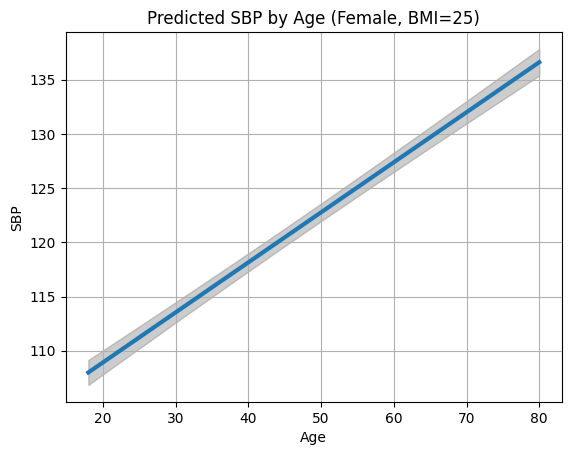

In [14]:
from statsmodels.sandbox.predict_functional import predict_functional

# Fix non-focus variables at reference values
values = {"gender_labeled": "Female", "gender": 1, "bmi": 25}

# The returned values are predicted values (pr), the confidence bands (cb), and the function values (fv)
preds, confidence_bands, function_values = predict_functional(result, "age", values=values, ci_method="simultaneous")

ax = sns.lineplot(x=function_values, y=preds, lw=3)
ax.grid(True)
ax.fill_between(function_values, confidence_bands[:,0], confidence_bands[:, 1], color="grey", alpha=0.4)
ax.set_title("Predicted SBP by Age (Female, BMI=25)")
ax.set_xlabel("Age")
ax.set_ylabel("SBP")
plt.show()

Now it's time for an analogous plot for BMI. Here we fix gender as "female" and the age at 50, so we're looking at the relationship between expected SBP and age for women of age 50.

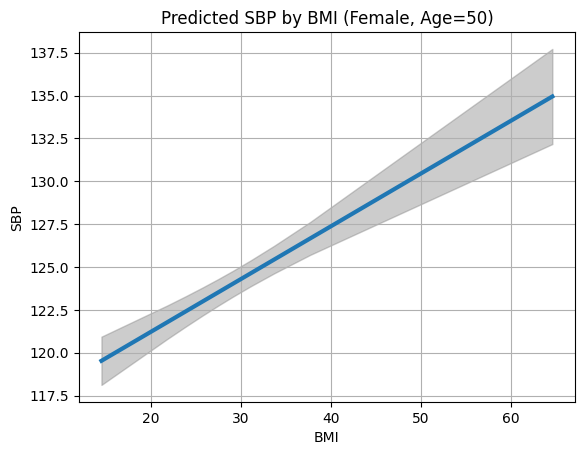

In [15]:
del values["bmi"] # We don't want our focus variable to remain fixed
values["age"] = 50
preds, confidence_bands, function_values = predict_functional(result, "bmi", values=values, ci_method="simultaneous")
ax = sns.lineplot(x=function_values, y=preds, lw=3)
ax.grid(True)
ax.fill_between(function_values, confidence_bands[:,0], confidence_bands[:, 1], color="grey", alpha=0.4)
ax.set_title("Predicted SBP by BMI (Female, Age=50)")
ax.set_xlabel("BMI")
ax.set_ylabel("SBP")
plt.show()

The error band for BMI is notably wider than the error band for age, indicating that our model has less certainty about the relationship between BMI and SBP compared to the relationship between age and SBP.

### Visualizing the Variance Structure of the Population
Let's now focus on informal, graphical methods for assessing the variance structure of the population. To begin with, we plot the residuals against the fitted values. 

The simplest variance pattern that we can see in a linear regression occurs when the points are scattered around the mean, with the same degree of scatter throughout the range of the covariates. When there are multiple covariates, it may be difficult to assess whether the variance is uniform throughout this range, but we can easily check for a "mean/variance relationship", in which there is a systematic relationship between the variance and the mean, i.e. the variance either increases or decreases systematically with the mean. 

The plot of residuals on fitted values is used to assess whether such a mean/variance relationship is present.

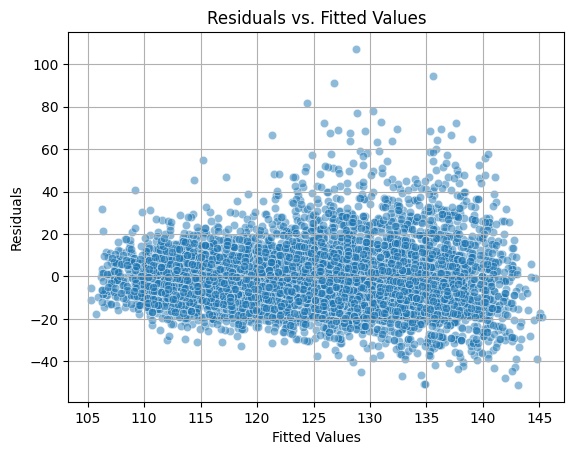

In [17]:
ax = sns.scatterplot(x=result.fittedvalues, y=result.resid, alpha=0.5)
ax.grid(True)
ax.set_title("Residuals vs. Fitted Values")
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
plt.show()

It appears that we have a modestly increasing mean/variance relationship. That is, the scatter around the mean blood pressure is greater when the mean blood pressure itself is greater.

If we want to see how the data would look if all but one covariate could by fixed at reference values, we use a **component plus residual plot** (a.k.a. partial residual plot). By controlling the values of these covariates, all remaining variation is due either to the focus variable (plotted on the horizontal axis), or to sources of variation that are unexplained by any of the covariates.

Let's use a partial residual plot to show how age and SBP are related for fixed values of gender and BMI.

> **Note:** The origin of the vertical axis in these plots is not meaningful (we're not implying that anyone's blood pressure would be negative), but the differences along the vertical axis are meaningful.

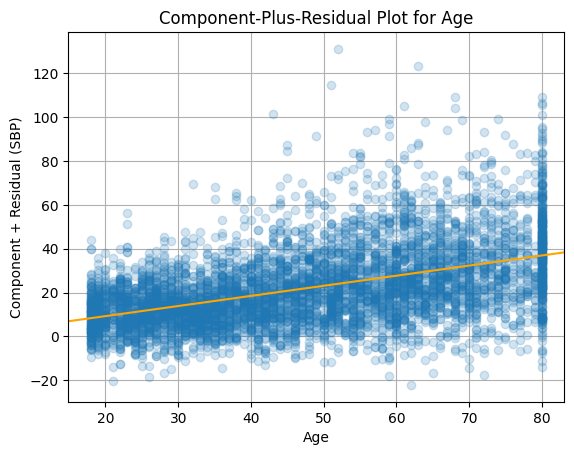

In [19]:
from statsmodels.graphics.regressionplots import plot_ccpr

ax = plt.axes()
plot_ccpr(result, "age", ax)
ax.lines[0].set_alpha(0.2) # Reduce overplotting with transparency
ax.lines[1].set_color('orange')
ax.set_title("Component-Plus-Residual Plot for Age")
ax.set_xlabel("Age")
ax.set_ylabel("Component + Residual (SBP)")
ax.grid(True)
plt.show()

The plot implies that: 
* When BMI and gender are held fixed, the average blood pressures of an 80 and 18 year old differ by around 30 units (mm/Hg). 
* The deviations from the mean are somewhat smaller at the low end of the range compared to the high end of the range. 
* At the high end of the range, the deviations from the mean are somewhat right-skewed, with exceptionally high SBP values being more common than exceptionally low SBP values.

Next we have a partial residual plot that shows how BMI and SBP would be related if gender and age were fixed.

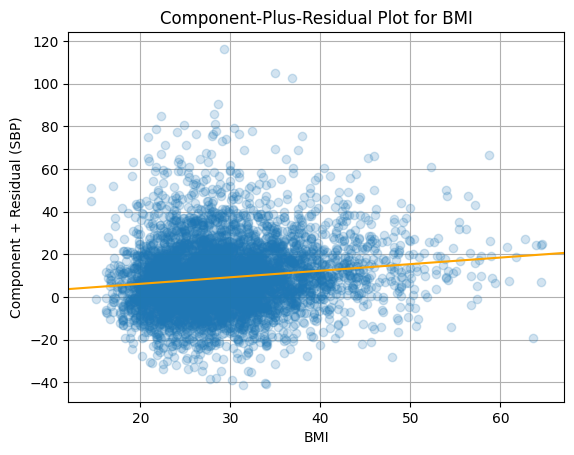

In [20]:
ax = plt.axes()
plot_ccpr(result, "bmi", ax)
ax.lines[0].set_alpha(0.2) # Reduce overplotting with transparency
ax.lines[1].set_color('orange')
ax.set_title("Component-Plus-Residual Plot for BMI")
ax.set_xlabel("BMI")
ax.set_ylabel("Component + Residual (SBP)")
ax.grid(True)
plt.show()

The plot shows that:
* BMI is **less** uniformly distributed than age was.
* There is more scatter in the partial residuals for BMI compared to for age. Thus there seems to be less information about SBP in BMI, although a trend certainly exists.

Another important plot used for understanding a regression model is an **added variable plot**. This is a plot that may reveal nonlinearity in the relationship between one covariate and the outcome.

Let's create an added variable plot for age as a predictor of SBP.

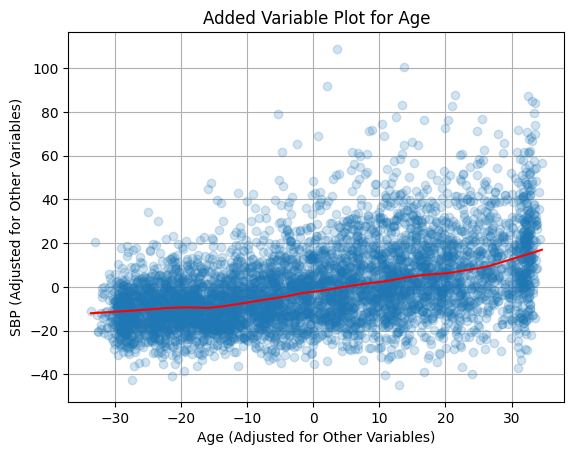

In [26]:
from statsmodels.graphics.regressionplots import add_lowess

# This is an equivalent way to fit a linear regression model, it needs to be 
# done this way to be able to make the added variable plot
model = sm.GLM.from_formula("sbp ~ age + bmi + gender_labeled", data=nhanes_df)
result = model.fit()

fig = result.plot_added_variable("age")
ax = fig.get_axes()[0]
ax.lines[0].set_alpha(0.2)
add_lowess(ax)
ax.set_xlabel("Age (Adjusted for Other Variables)", fontsize=10)
ax.set_ylabel("SBP (Adjusted for Other Variables)", fontsize=10)
ax.set_title("Added Variable Plot for Age")
ax.grid(True)
plt.show()

Note that the two variables plotted have been centered. The scale of the variables is unchanged, but the origin has been translated to zero. 

The red line is an estimate of the relationship between age and blood pressure. Unlike the relationship in the model, it is not forced to be linear, and there is in fact a hint that the shape is slightly flatter for the first 15 years or so of age. This would imply that blood pressure increases slightly more slowly for people in their 20s and early 30s, then begins increasing faster after that point.

---

**Next:** [Logistic Regression in Python](./10_logistic_regression_in_python.ipynb)